# 11 — Customer Churn Proxy Analysis

## Behavioral inactivity under explicit assumptions

## Objective

This notebook demonstrates a churn-style analytical workflow by defining a customer inactivity proxy from observed purchasing behavior.

The analysis will:

- Separate a historical feature window from a future outcome window
- Prevent future information from leaking into customer features
- Define a reproducible inactivity-based proxy
- Compare customers who returned with those not observed returning
- Evaluate sensitivity to alternative time windows
- Prepare a modeling-ready customer table

## Important limitation

The Olist dataset contains no confirmed churn event, account closure, subscription cancellation, or expected purchasing schedule. Therefore, the target created here is an analytical proxy for **not observed returning**, not verified customer churn.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.ticker import PercentFormatter

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

DATA_DIR = Path("../data/processed")
IMAGES_DIR = Path("../images/notebook_outputs")

IMAGES_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {
    "primary": "#173F5F",
    "secondary": "#20639B",
    "accent": "#F6C85F",
    "positive": "#3CAEA3",
    "negative": "#ED553B",
    "neutral": "#8A8A8A"
}

order_analytics = pd.read_csv(
    DATA_DIR / "order_analytics.csv",
    parse_dates=["order_purchase_timestamp"]
)

delivered_orders = (
    order_analytics.loc[
        (order_analytics["order_status"] == "delivered")
        & order_analytics["customer_unique_id"].notna()
    ]
    .copy()
)

print(
    "Delivered orders loaded:",
    f"{len(delivered_orders):,}"
)
print(
    "Customers represented:",
    f"{delivered_orders['customer_unique_id'].nunique():,}"
)
print(
    "Delivered-purchase period:",
    delivered_orders[
        "order_purchase_timestamp"
    ].min().date(),
    "to",
    delivered_orders[
        "order_purchase_timestamp"
    ].max().date()
)

Delivered orders loaded: 96,478
Customers represented: 93,358
Delivered-purchase period: 2016-09-15 to 2018-08-29


In [2]:
feature_cutoff = pd.Timestamp("2018-03-01")

outcome_end = (
    delivered_orders[
        "order_purchase_timestamp"
    ].max().normalize()
    + pd.Timedelta(days=1)
)

feature_orders = (
    delivered_orders.loc[
        delivered_orders[
            "order_purchase_timestamp"
        ] < feature_cutoff
    ]
    .copy()
)

outcome_orders = (
    delivered_orders.loc[
        delivered_orders[
            "order_purchase_timestamp"
        ].between(
            feature_cutoff,
            outcome_end,
            inclusive="left"
        )
    ]
    .copy()
)

eligible_customers = (
    feature_orders["customer_unique_id"]
    .drop_duplicates()
)

returning_customer_ids = set(
    outcome_orders["customer_unique_id"].unique()
)

customer_outcomes = pd.DataFrame({
    "customer_unique_id": eligible_customers
})

customer_outcomes["returned_in_outcome_window"] = (
    customer_outcomes["customer_unique_id"]
    .isin(returning_customer_ids)
)

customer_outcomes["inactivity_proxy"] = (
    ~customer_outcomes[
        "returned_in_outcome_window"
    ]
).astype(int)

customer_outcomes["proxy_status"] = np.where(
    customer_outcomes["returned_in_outcome_window"],
    "Returned during outcome window",
    "Not observed returning"
)

outcome_summary = (
    customer_outcomes
    .groupby("proxy_status", as_index=False)
    .agg(
        customers=("customer_unique_id", "nunique")
    )
)

outcome_summary["customer_share"] = (
    outcome_summary["customers"]
    / outcome_summary["customers"].sum()
)

print(
    "Feature window:",
    feature_orders[
        "order_purchase_timestamp"
    ].min().date(),
    "to",
    (feature_cutoff - pd.Timedelta(days=1)).date()
)

print(
    "Outcome window:",
    feature_cutoff.date(),
    "to",
    (outcome_end - pd.Timedelta(days=1)).date()
)

print(
    "Eligible customers:",
    f"{len(customer_outcomes):,}"
)

display(
    outcome_summary.style.format({
        "customers": "{:,.0f}",
        "customer_share": "{:.2%}"
    })
)

Feature window: 2016-09-15 to 2018-02-28
Outcome window: 2018-03-01 to 2018-08-29
Eligible customers: 55,525


,proxy_status,customers,customer_share
0,Not observed returning,"54,871",98.82%
1,Returned during outcome window,654,1.18%


In [5]:
feature_orders["low_review_flag"] = (
    feature_orders["latest_review_score"]
    .le(2)
    .where(
        feature_orders[
            "latest_review_score"
        ].notna()
    )
)

feature_orders["late_delivery_for_analysis"] = (
    pd.to_numeric(
        feature_orders["late_delivery_flag_numeric"],
        errors="coerce"
    )
    .where(
        feature_orders[
            "is_valid_for_delivery_analysis"
        ]
    )
)

feature_orders["multi_item_order"] = (
    feature_orders["item_count"] > 1
)

feature_orders["multi_seller_order"] = (
    feature_orders["distinct_seller_count"] > 1
)

customer_features = (
    feature_orders
    .groupby("customer_unique_id", as_index=False)
    .agg(
        first_purchase_date=(
            "order_purchase_timestamp",
            "min"
        ),
        last_purchase_date=(
            "order_purchase_timestamp",
            "max"
        ),
        observed_orders=("order_id", "nunique"),
        observed_payment_value=(
            "total_payment_value",
            lambda values: values.sum(min_count=1)
        ),
        average_order_payment=(
            "total_payment_value",
            "mean"
        ),
        average_product_value=(
            "product_value",
            "mean"
        ),
        average_freight_value=(
            "freight_value",
            "mean"
        ),
        reviewed_orders=(
            "latest_review_score",
            "count"
        ),
        average_review_score=(
            "latest_review_score",
            "mean"
        ),
        low_satisfaction_rate=(
            "low_review_flag",
            "mean"
        ),
        written_feedback_rate=(
            "has_written_feedback",
            "mean"
        ),
        valid_delivery_orders=(
            "late_delivery_for_analysis",
            "count"
        ),
        late_delivery_rate=(
            "late_delivery_for_analysis",
            "mean"
        ),
        average_delivery_days=(
            "delivery_days",
            "mean"
        ),
        average_item_count=(
            "item_count",
            "mean"
        ),
        multi_item_order_rate=(
            "multi_item_order",
            "mean"
        ),
        multi_seller_order_rate=(
            "multi_seller_order",
            "mean"
        )
    )
)

customer_features["recency_days_at_cutoff"] = (
    feature_cutoff
    - customer_features[
        "last_purchase_date"
    ].dt.normalize()
).dt.days

customer_features["observed_purchase_span_days"] = (
    customer_features[
        "last_purchase_date"
    ].dt.normalize()
    - customer_features[
        "first_purchase_date"
    ].dt.normalize()
).dt.days

churn_proxy_data = (
    customer_features
    .merge(
        customer_outcomes,
        on="customer_unique_id",
        how="inner",
        validate="one_to_one"
    )
)

feature_validation = pd.DataFrame([
    {
        "validation_check": "Eligible customers represented",
        "result": len(churn_proxy_data),
        "expected": len(customer_outcomes)
    },
    {
        "validation_check": "Duplicate customer IDs",
        "result": churn_proxy_data[
            "customer_unique_id"
        ].duplicated().sum(),
        "expected": 0
    },
    {
        "validation_check": "Feature orders on or after cutoff",
        "result": (
            feature_orders[
                "order_purchase_timestamp"
            ] >= feature_cutoff
        ).sum(),
        "expected": 0
    },
    {
        "validation_check": "Missing proxy labels",
        "result": churn_proxy_data[
            "inactivity_proxy"
        ].isna().sum(),
        "expected": 0
    },
    {
        "validation_check": "Negative cutoff recency",
        "result": (
            churn_proxy_data[
                "recency_days_at_cutoff"
            ] < 0
        ).sum(),
        "expected": 0
    }
])

feature_validation["status"] = np.where(
    feature_validation["result"]
    == feature_validation["expected"],
    "Passed",
    "Failed"
)

display(feature_validation)

print(
    "Modeling-table rows:",
    f"{len(churn_proxy_data):,}"
)
print(
    "Modeling-table columns:",
    churn_proxy_data.shape[1]
)

,validation_check,result,expected,status
0,Eligible customers represented,55525,55525,Passed
1,Duplicate customer IDs,0,0,Passed
2,Feature orders on or after cutoff,0,0,Passed
3,Missing proxy labels,0,0,Passed
4,Negative cutoff recency,0,0,Passed


Modeling-table rows: 55,525
Modeling-table columns: 23


In [6]:
churn_proxy_data["pre_cutoff_repeat_customer"] = (
    churn_proxy_data["observed_orders"] > 1
)

proxy_profile = (
    churn_proxy_data
    .groupby("proxy_status", as_index=False)
    .agg(
        customers=("customer_unique_id", "nunique"),
        average_recency_days=(
            "recency_days_at_cutoff",
            "mean"
        ),
        median_recency_days=(
            "recency_days_at_cutoff",
            "median"
        ),
        average_observed_orders=(
            "observed_orders",
            "mean"
        ),
        pre_cutoff_repeat_rate=(
            "pre_cutoff_repeat_customer",
            "mean"
        ),
        average_observed_payment=(
            "observed_payment_value",
            "mean"
        ),
        median_observed_payment=(
            "observed_payment_value",
            "median"
        ),
        average_review_score=(
            "average_review_score",
            "mean"
        ),
        average_low_satisfaction_rate=(
            "low_satisfaction_rate",
            "mean"
        ),
        average_late_delivery_rate=(
            "late_delivery_rate",
            "mean"
        ),
        average_delivery_days=(
            "average_delivery_days",
            "mean"
        ),
        average_multi_item_rate=(
            "multi_item_order_rate",
            "mean"
        ),
        average_multi_seller_rate=(
            "multi_seller_order_rate",
            "mean"
        )
    )
)

proxy_profile["customer_share"] = (
    proxy_profile["customers"]
    / proxy_profile["customers"].sum()
)

proxy_profile = (
    proxy_profile
    .sort_values(
        "proxy_status",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    proxy_profile.style.format({
        "customers": "{:,.0f}",
        "average_recency_days": "{:,.1f}",
        "median_recency_days": "{:,.1f}",
        "average_observed_orders": "{:.2f}",
        "pre_cutoff_repeat_rate": "{:.2%}",
        "average_observed_payment": "R$ {:,.2f}",
        "median_observed_payment": "R$ {:,.2f}",
        "average_review_score": "{:.2f}",
        "average_low_satisfaction_rate": "{:.2%}",
        "average_late_delivery_rate": "{:.2%}",
        "average_delivery_days": "{:.2f}",
        "average_multi_item_rate": "{:.2%}",
        "average_multi_seller_rate": "{:.2%}",
        "customer_share": "{:.2%}"
    })
)

,proxy_status,customers,average_recency_days,median_recency_days,average_observed_orders,pre_cutoff_repeat_rate,average_observed_payment,median_observed_payment,average_review_score,average_low_satisfaction_rate,average_late_delivery_rate,average_delivery_days,average_multi_item_rate,average_multi_seller_rate,customer_share
0,Returned during outcome window,654,132.7,105.0,1.17,10.40%,R$ 162.68,R$ 114.27,4.23,11.73%,6.01%,12.68,14.51%,1.45%,1.18%
1,Not observed returning,"54,871",158.1,135.0,1.03,2.83%,R$ 162.35,R$ 106.16,4.13,13.20%,6.65%,13.67,9.85%,1.07%,98.82%


In [8]:
recency_bins = [
    0,
    30,
    60,
    90,
    180,
    365,
    np.inf
]

recency_labels = [
    "1–30 days",
    "31–60 days",
    "61–90 days",
    "91–180 days",
    "181–365 days",
    "More than 365 days"
]

churn_proxy_data["recency_group"] = pd.cut(
    churn_proxy_data["recency_days_at_cutoff"],
    bins=recency_bins,
    labels=recency_labels,
    include_lowest=True,
    ordered=True
)

recency_proxy_summary = (
    churn_proxy_data
    .groupby(
        "recency_group",
        observed=True,
        as_index=False
    )
    .agg(
        customers=("customer_unique_id", "nunique"),
        returned_customers=(
            "returned_in_outcome_window",
            "sum"
        ),
        observed_return_rate=(
            "returned_in_outcome_window",
            "mean"
        ),
        inactivity_proxy_rate=(
            "inactivity_proxy",
            "mean"
        ),
        average_pre_cutoff_orders=(
            "observed_orders",
            "mean"
        ),
        average_observed_payment=(
            "observed_payment_value",
            "mean"
        )
    )
)

recency_proxy_summary["customer_share"] = (
    recency_proxy_summary["customers"]
    / recency_proxy_summary["customers"].sum()
)

display(
    recency_proxy_summary.style.format({
        "customers": "{:,.0f}",
        "returned_customers": "{:,.0f}",
        "observed_return_rate": "{:.2%}",
        "inactivity_proxy_rate": "{:.2%}",
        "average_pre_cutoff_orders": "{:.2f}",
        "average_observed_payment": "R$ {:,.2f}",
        "customer_share": "{:.2%}"
    })
)

print(
    "Customers represented:",
    f"{recency_proxy_summary['customers'].sum():,}"
)

,recency_group,customers,returned_customers,observed_return_rate,inactivity_proxy_rate,average_pre_cutoff_orders,average_observed_payment,customer_share
0,1–30 days,"6,888",122,1.77%,98.23%,1.04,R$ 154.06,12.41%
1,31–60 days,"6,529",102,1.56%,98.44%,1.04,R$ 158.52,11.76%
2,61–90 days,"5,349",61,1.14%,98.86%,1.03,R$ 158.17,9.63%
3,91–180 days,"15,303",168,1.10%,98.90%,1.03,R$ 168.51,27.56%
4,181–365 days,"18,911",182,0.96%,99.04%,1.03,R$ 161.63,34.06%
5,More than 365 days,"2,545",19,0.75%,99.25%,1.02,R$ 171.84,4.58%


Customers represented: 55,525


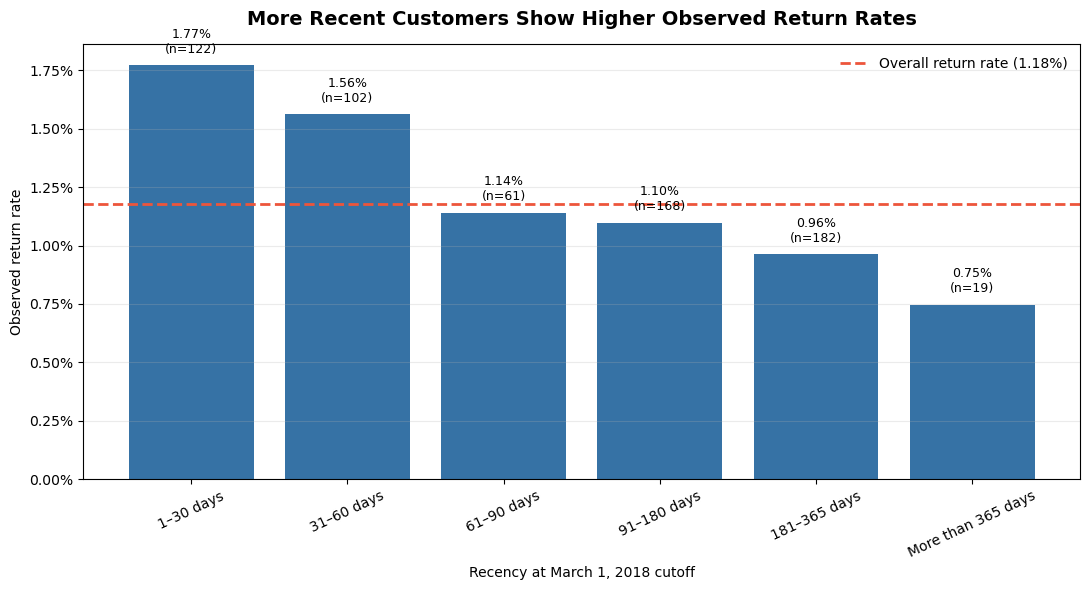

In [9]:
fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(
    recency_proxy_summary[
        "recency_group"
    ].astype(str),
    recency_proxy_summary[
        "observed_return_rate"
    ],
    color=COLORS["secondary"],
    alpha=0.9
)

overall_return_rate = (
    churn_proxy_data[
        "returned_in_outcome_window"
    ].mean()
)

ax.axhline(
    overall_return_rate,
    color=COLORS["negative"],
    linestyle="--",
    linewidth=2,
    label=f"Overall return rate ({overall_return_rate:.2%})"
)

for bar, rate, count in zip(
    bars,
    recency_proxy_summary[
        "observed_return_rate"
    ],
    recency_proxy_summary[
        "returned_customers"
    ]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        rate + 0.0004,
        f"{rate:.2%}\n(n={int(count):,})",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel("Recency at March 1, 2018 cutoff")
ax.set_ylabel("Observed return rate")

ax.set_title(
    "More Recent Customers Show Higher Observed Return Rates",
    fontsize=14,
    fontweight="bold",
    pad=14
)

ax.tick_params(axis="x", rotation=25)
ax.legend(frameon=False)
ax.grid(axis="x", visible=False)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()

plt.savefig(
    IMAGES_DIR / "proxy_return_rate_by_recency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

***Observation:*** Customers whose latest pre-cutoff purchase occurred within 30 days show a 1.77% observed return rate, compared with 0.75% for customers inactive for more than 365 days. Recency is associated with the proxy outcome, but the chart does not establish causation or predict individual churn.

In [10]:
frequency_bins = [0, 1, 2, np.inf]

frequency_labels = [
    "1 observed order",
    "2 observed orders",
    "3 or more observed orders"
]

churn_proxy_data["frequency_group"] = pd.cut(
    churn_proxy_data["observed_orders"],
    bins=frequency_bins,
    labels=frequency_labels,
    include_lowest=True,
    ordered=True
)

frequency_proxy_summary = (
    churn_proxy_data
    .groupby(
        "frequency_group",
        observed=True,
        as_index=False
    )
    .agg(
        customers=("customer_unique_id", "nunique"),
        returned_customers=(
            "returned_in_outcome_window",
            "sum"
        ),
        observed_return_rate=(
            "returned_in_outcome_window",
            "mean"
        ),
        inactivity_proxy_rate=(
            "inactivity_proxy",
            "mean"
        ),
        average_recency_days=(
            "recency_days_at_cutoff",
            "mean"
        ),
        average_observed_payment=(
            "observed_payment_value",
            "mean"
        )
    )
)

frequency_proxy_summary["customer_share"] = (
    frequency_proxy_summary["customers"]
    / frequency_proxy_summary["customers"].sum()
)

display(
    frequency_proxy_summary.style.format({
        "customers": "{:,.0f}",
        "returned_customers": "{:,.0f}",
        "observed_return_rate": "{:.2%}",
        "inactivity_proxy_rate": "{:.2%}",
        "average_recency_days": "{:,.1f}",
        "average_observed_payment": "R$ {:,.2f}",
        "customer_share": "{:.2%}"
    })
)

print(
    "Customers represented:",
    f"{frequency_proxy_summary['customers'].sum():,}"
)

,frequency_group,customers,returned_customers,observed_return_rate,inactivity_proxy_rate,average_recency_days,average_observed_payment,customer_share
0,1 observed order,"53,902",586,1.09%,98.91%,158.4,R$ 158.15,97.08%
1,2 observed orders,"1,499",47,3.14%,96.86%,139.6,R$ 288.93,2.70%
2,3 or more observed orders,124,21,16.94%,83.06%,138.5,R$ 460.56,0.22%


Customers represented: 55,525


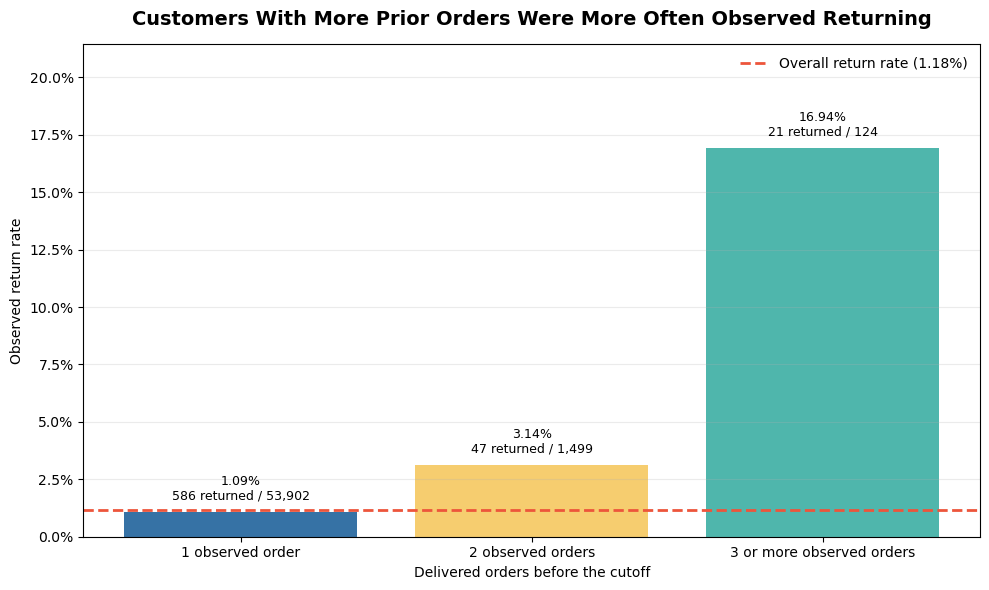

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = [
    COLORS["secondary"],
    COLORS["accent"],
    COLORS["positive"]
]

bars = ax.bar(
    frequency_proxy_summary[
        "frequency_group"
    ].astype(str),
    frequency_proxy_summary[
        "observed_return_rate"
    ],
    color=bar_colors,
    alpha=0.9
)

ax.axhline(
    overall_return_rate,
    color=COLORS["negative"],
    linestyle="--",
    linewidth=2,
    label=f"Overall return rate ({overall_return_rate:.2%})"
)

for bar, rate, customers, returned in zip(
    bars,
    frequency_proxy_summary[
        "observed_return_rate"
    ],
    frequency_proxy_summary["customers"],
    frequency_proxy_summary[
        "returned_customers"
    ]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        rate + 0.004,
        (
            f"{rate:.2%}\n"
            f"{int(returned):,} returned / "
            f"{int(customers):,}"
        ),
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel("Delivered orders before the cutoff")
ax.set_ylabel("Observed return rate")

ax.set_title(
    "Customers With More Prior Orders Were More Often Observed Returning",
    fontsize=14,
    fontweight="bold",
    pad=14
)

ax.set_ylim(
    0,
    frequency_proxy_summary[
        "observed_return_rate"
    ].max() + 0.045
)

ax.legend(frameon=False)
ax.grid(axis="x", visible=False)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()

plt.savefig(
    IMAGES_DIR / "proxy_return_rate_by_frequency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

***Observation:*** Observed return increases with pre-cutoff order frequency, reaching 16.94% among customers with at least three prior delivered orders. That group contains only 124 customers, so the result is a useful behavioral signal but not a stable estimate of individual churn probability.

In [12]:
outcome_horizons = [90, 120, 180]

sensitivity_records = []

for horizon_days in outcome_horizons:
    horizon_end = (
        feature_cutoff
        + pd.Timedelta(days=horizon_days)
    )

    returned_ids = (
        delivered_orders.loc[
            delivered_orders[
                "order_purchase_timestamp"
            ].between(
                feature_cutoff,
                horizon_end,
                inclusive="left"
            ),
            "customer_unique_id"
        ]
        .unique()
    )

    returned_count = (
        customer_outcomes[
            "customer_unique_id"
        ]
        .isin(returned_ids)
        .sum()
    )

    eligible_count = len(customer_outcomes)
    not_returned_count = (
        eligible_count - returned_count
    )

    sensitivity_records.append({
        "outcome_window_days": horizon_days,
        "outcome_end_exclusive": horizon_end,
        "eligible_customers": eligible_count,
        "returned_customers": returned_count,
        "not_observed_returning": not_returned_count,
        "observed_return_rate": (
            returned_count / eligible_count
        ),
        "inactivity_proxy_rate": (
            not_returned_count / eligible_count
        )
    })

proxy_sensitivity = pd.DataFrame(
    sensitivity_records
)

display(
    proxy_sensitivity.style.format({
        "outcome_end_exclusive": "{:%Y-%m-%d}",
        "eligible_customers": "{:,.0f}",
        "returned_customers": "{:,.0f}",
        "not_observed_returning": "{:,.0f}",
        "observed_return_rate": "{:.2%}",
        "inactivity_proxy_rate": "{:.2%}"
    })
)

sensitivity_validation = pd.DataFrame([
    {
        "validation_check": "Changing eligible populations",
        "result": proxy_sensitivity[
            "eligible_customers"
        ].nunique(),
        "expected": 1
    },
    {
        "validation_check": "Invalid sensitivity rates",
        "result": (
            ~proxy_sensitivity[
                "observed_return_rate"
            ].between(0, 1)
        ).sum(),
        "expected": 0
    },
    {
        "validation_check":
            "Return counts decreasing with longer windows",
        "result": (
            proxy_sensitivity[
                "returned_customers"
            ].diff().dropna() < 0
        ).sum(),
        "expected": 0
    }
])

sensitivity_validation["status"] = np.where(
    sensitivity_validation["result"]
    == sensitivity_validation["expected"],
    "Passed",
    "Failed"
)

display(sensitivity_validation)

,outcome_window_days,outcome_end_exclusive,eligible_customers,returned_customers,not_observed_returning,observed_return_rate,inactivity_proxy_rate
0,90,2018-05-30,"55,525",386,"55,139",0.70%,99.30%
1,120,2018-06-29,"55,525",488,"55,037",0.88%,99.12%
2,180,2018-08-28,"55,525",653,"54,872",1.18%,98.82%


,validation_check,result,expected,status
0,Changing eligible populations,1,1,Passed
1,Invalid sensitivity rates,0,0,Passed
2,Return counts decreasing with longer windows,0,0,Passed


In [13]:
model_feature_columns = [
    "recency_days_at_cutoff",
    "observed_orders",
    "observed_payment_value",
    "average_order_payment",
    "average_product_value",
    "average_freight_value",
    "reviewed_orders",
    "average_review_score",
    "low_satisfaction_rate",
    "written_feedback_rate",
    "valid_delivery_orders",
    "late_delivery_rate",
    "average_delivery_days",
    "average_item_count",
    "multi_item_order_rate",
    "multi_seller_order_rate",
    "observed_purchase_span_days"
]

feature_audit_records = []

for column in model_feature_columns:
    feature_audit_records.append({
        "feature": column,
        "data_type": str(
            churn_proxy_data[column].dtype
        ),
        "non_null_values": (
            churn_proxy_data[column].notna().sum()
        ),
        "missing_values": (
            churn_proxy_data[column].isna().sum()
        ),
        "missing_rate": (
            churn_proxy_data[column].isna().mean()
        ),
        "unique_values": (
            churn_proxy_data[column].nunique(
                dropna=True
            )
        )
    })

feature_audit = pd.DataFrame(
    feature_audit_records
)

display(
    feature_audit.style.format({
        "non_null_values": "{:,.0f}",
        "missing_values": "{:,.0f}",
        "missing_rate": "{:.2%}",
        "unique_values": "{:,.0f}"
    })
)

print(
    "Features audited:",
    len(model_feature_columns)
)
print(
    "Features containing missing values:",
    f"{(feature_audit['missing_values'] > 0).sum():,}"
)

,feature,data_type,non_null_values,missing_values,missing_rate,unique_values
0,recency_days_at_cutoff,int64,"55,525",0,0.00%,429
1,observed_orders,int64,"55,525",0,0.00%,9
2,observed_payment_value,float64,"55,524",1,0.00%,"18,631"
3,average_order_payment,float64,"55,524",1,0.00%,"18,672"
4,average_product_value,float64,"55,525",0,0.00%,"6,039"
5,average_freight_value,float64,"55,525",0,0.00%,"6,306"
6,reviewed_orders,int64,"55,525",0,0.00%,10
7,average_review_score,float64,"55,118",407,0.73%,22
8,low_satisfaction_rate,object,"55,118",407,0.73%,8
9,written_feedback_rate,float64,"55,525",0,0.00%,10


Features audited: 17
Features containing missing values: 6


In [14]:
churn_proxy_data["low_satisfaction_rate"] = (
    pd.to_numeric(
        churn_proxy_data["low_satisfaction_rate"],
        errors="coerce"
    )
)

churn_proxy_data["payment_feature_available"] = (
    churn_proxy_data[
        "observed_payment_value"
    ].notna()
)

churn_proxy_data["review_feature_available"] = (
    churn_proxy_data[
        "average_review_score"
    ].notna()
)

churn_proxy_data["delivery_feature_available"] = (
    churn_proxy_data[
        "average_delivery_days"
    ].notna()
)

model_feature_columns = [
    "recency_days_at_cutoff",
    "observed_orders",
    "observed_payment_value",
    "average_order_payment",
    "payment_feature_available",
    "average_product_value",
    "average_freight_value",
    "reviewed_orders",
    "average_review_score",
    "low_satisfaction_rate",
    "written_feedback_rate",
    "review_feature_available",
    "valid_delivery_orders",
    "late_delivery_rate",
    "average_delivery_days",
    "delivery_feature_available",
    "average_item_count",
    "multi_item_order_rate",
    "multi_seller_order_rate",
    "observed_purchase_span_days"
]

feature_audit = pd.DataFrame([
    {
        "feature": column,
        "data_type": str(
            churn_proxy_data[column].dtype
        ),
        "non_null_values": (
            churn_proxy_data[column].notna().sum()
        ),
        "missing_values": (
            churn_proxy_data[column].isna().sum()
        ),
        "missing_rate": (
            churn_proxy_data[column].isna().mean()
        ),
        "unique_values": (
            churn_proxy_data[column].nunique(
                dropna=True
            )
        )
    }
    for column in model_feature_columns
])

display(
    feature_audit.style.format({
        "non_null_values": "{:,.0f}",
        "missing_values": "{:,.0f}",
        "missing_rate": "{:.2%}",
        "unique_values": "{:,.0f}"
    })
)

print(
    "Low-satisfaction data type:",
    churn_proxy_data[
        "low_satisfaction_rate"
    ].dtype
)
print(
    "Modeling features documented:",
    len(model_feature_columns)
)

,feature,data_type,non_null_values,missing_values,missing_rate,unique_values
0,recency_days_at_cutoff,int64,"55,525",0,0.00%,429
1,observed_orders,int64,"55,525",0,0.00%,9
2,observed_payment_value,float64,"55,524",1,0.00%,"18,631"
3,average_order_payment,float64,"55,524",1,0.00%,"18,672"
4,payment_feature_available,bool,"55,525",0,0.00%,2
5,average_product_value,float64,"55,525",0,0.00%,"6,039"
6,average_freight_value,float64,"55,525",0,0.00%,"6,306"
7,reviewed_orders,int64,"55,525",0,0.00%,10
8,average_review_score,float64,"55,118",407,0.73%,22
9,low_satisfaction_rate,float64,"55,118",407,0.73%,8


Low-satisfaction data type: float64
Modeling features documented: 20


In [15]:
final_validation = pd.DataFrame([
    {
        "validation_check": "Eligible customer rows",
        "result": len(churn_proxy_data),
        "expected": 55_525
    },
    {
        "validation_check": "Duplicate customer IDs",
        "result": churn_proxy_data[
            "customer_unique_id"
        ].duplicated().sum(),
        "expected": 0
    },
    {
        "validation_check": "Returned customers represented",
        "result": churn_proxy_data[
            "returned_in_outcome_window"
        ].sum(),
        "expected": 654
    },
    {
        "validation_check": "Invalid proxy labels",
        "result": (
            ~churn_proxy_data[
                "inactivity_proxy"
            ].isin([0, 1])
        ).sum(),
        "expected": 0
    },
    {
        "validation_check": "Feature-window leakage",
        "result": (
            feature_orders[
                "order_purchase_timestamp"
            ] >= feature_cutoff
        ).sum(),
        "expected": 0
    },
    {
        "validation_check": "Documented modeling features",
        "result": len(model_feature_columns),
        "expected": 20
    },
    {
        "validation_check":
            "Non-numeric low-satisfaction feature",
        "result": int(
            not pd.api.types.is_numeric_dtype(
                churn_proxy_data[
                    "low_satisfaction_rate"
                ]
            )
        ),
        "expected": 0
    },
    {
        "validation_check":
            "Sensitivity population changes",
        "result": proxy_sensitivity[
            "eligible_customers"
        ].nunique(),
        "expected": 1
    }
])

final_validation["status"] = np.where(
    final_validation["result"]
    == final_validation["expected"],
    "Passed",
    "Failed"
)

display(final_validation)

,validation_check,result,expected,status
0,Eligible customer rows,55525,55525,Passed
1,Duplicate customer IDs,0,0,Passed
2,Returned customers represented,654,654,Passed
3,Invalid proxy labels,0,0,Passed
4,Feature-window leakage,0,0,Passed
5,Documented modeling features,20,20,Passed
6,Non-numeric low-satisfaction feature,0,0,Passed
7,Sensitivity population changes,1,1,Passed


In [16]:
analysis_metadata = pd.DataFrame({
    "parameter": [
        "feature_window_start",
        "feature_window_end",
        "outcome_window_start",
        "outcome_window_end",
        "eligible_customers",
        "returned_customers",
        "proxy_definition"
    ],
    "value": [
        feature_orders[
            "order_purchase_timestamp"
        ].min().date(),
        (
            feature_cutoff
            - pd.Timedelta(days=1)
        ).date(),
        feature_cutoff.date(),
        (
            outcome_end
            - pd.Timedelta(days=1)
        ).date(),
        len(churn_proxy_data),
        int(
            churn_proxy_data[
                "returned_in_outcome_window"
            ].sum()
        ),
        (
            "1 = customer was not observed making a "
            "delivered purchase during the outcome window"
        )
    ]
})

export_files = {
    "customer_churn_proxy_features.csv":
        churn_proxy_data,
    "churn_proxy_outcome_summary.csv":
        outcome_summary,
    "churn_proxy_behavior_profile.csv":
        behavior_profile,
    "churn_proxy_experience_profile.csv":
        experience_profile,
    "churn_proxy_recency_summary.csv":
        recency_proxy_summary,
    "churn_proxy_frequency_summary.csv":
        frequency_proxy_summary,
    "churn_proxy_sensitivity.csv":
        proxy_sensitivity,
    "churn_proxy_feature_audit.csv":
        feature_audit,
    "churn_proxy_analysis_metadata.csv":
        analysis_metadata,
    "churn_proxy_validation_report.csv":
        final_validation
}

for filename, dataframe in export_files.items():
    dataframe.to_csv(
        DATA_DIR / filename,
        index=False
    )

all_files_created = all(
    (DATA_DIR / filename).exists()
    for filename in export_files
)

print(
    "Churn-proxy files exported:",
    len(export_files)
)
print(
    "All churn-proxy files created:",
    all_files_created
)

Churn-proxy files exported: 10
All churn-proxy files created: True


## Conclusion

***Key findings:***

- The fixed-cutoff population contains 55,525 customers, of whom 654 (1.18%) were observed purchasing during the subsequent outcome window.
- Customers observed returning had a lower median cutoff recency: 105 days compared with 135 days among customers not observed returning.
- Pre-cutoff repeat purchasing was more common among returning customers: 10.40% compared with 2.83%.
- Observed return declined from 1.77% for customers purchasing within 30 days of the cutoff to 0.75% for those inactive for more than 365 days.
- Customers with three or more prior orders had a 16.94% observed return rate, although this group contained only 124 customers.
- Changing the outcome window from 90 to 180 days reduced the inactivity-proxy rate from 99.30% to 98.82%.
- Twenty pre-cutoff behavioral and experience features were documented without future-information leakage.

***Interpretation:*** Recency and prior purchase frequency are associated with the inactivity proxy, while historical payment value differs very little between the two outcome groups. The proxy is highly imbalanced and must not be described as confirmed churn or individual churn probability.

***Limitations:*** Olist is not treated as a subscription business, and the dataset contains no confirmed cancellation, account closure, or churn event. Purchases outside the observation period are unavailable.

***Outputs:*** The modeling-ready proxy table, group profiles, sensitivity results, feature audit, methodology metadata, and validation report were exported.